In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# make plots look nicer
sns.set_style("whitegrid")

In [10]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer # For handling missing values

In [11]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [12]:
df = pd.read_csv("Supermart.csv")

df.head(10)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
5,699-14-3026,Giza,Naypyitaw,Member,Female,Electronic accessories,85.39,7,29.8865,627.6165,3/25/2019,6:30:00 PM,Ewallet,597.73,4.761905,29.8865,4.1
6,355-53-5943,Alex,Yangon,Member,Female,Electronic accessories,68.84,6,20.6520,433.6920,2/25/2019,2:36:00 PM,Ewallet,413.04,4.761905,20.6520,5.8
7,315-22-5665,Giza,Naypyitaw,Member,Female,Home and lifestyle,73.56,10,36.7800,772.3800,2/24/2019,11:38:00 AM,Ewallet,735.60,4.761905,36.7800,8.0
8,665-32-9167,Alex,Yangon,Member,Female,Health and beauty,36.26,2,3.6260,76.1460,1/10/2019,5:15:00 PM,Credit card,72.52,4.761905,3.6260,7.2
9,692-92-5582,Cairo,Mandalay,Member,Female,Food and beverages,54.84,3,8.2260,172.7460,2/20/2019,1:27:00 PM,Credit card,164.52,4.761905,8.2260,5.9


In [17]:
# dataset shape
print("Shape:", df.shape)

# column names
print("Columns:", df.columns)

# data types
df.info()

Shape: (1000, 17)
Columns: Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales    

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unit price,1000.0,55.672130,26.494628,10.080000,32.875000,55.230000,77.935000,99.960000
Quantity,1000.0,5.510000,2.923431,1.000000,3.000000,5.000000,8.000000,10.000000
Tax 5%,1000.0,15.379369,11.708825,0.508500,5.924875,12.088000,22.445250,49.650000
Sales,1000.0,322.966749,245.885335,10.678500,124.422375,253.848000,471.350250,1042.650000
cogs,1000.0,307.587380,234.176510,10.170000,118.497500,241.760000,448.905000,993.000000
gross margin percentage,1000.0,4.761905,0.000000,4.761905,4.761905,4.761905,4.761905,4.761905
gross income,1000.0,15.379369,11.708825,0.508500,5.924875,12.088000,22.445250,49.650000
Rating,1000.0,6.972700,1.718580,4.000000,5.500000,7.000000,8.500000,10.000000


In [21]:

df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [22]:
df["Date"] = pd.to_datetime(df["Date"])

df["Time"] = pd.to_datetime(df["Time"])

# Create new useful features
df["Hour"] = df["Time"].dt.hour
df["Day"] = df["Date"].dt.day_name()
df["Month"] = df["Date"].dt.month 

C:\Users\ACER\AppData\Local\Temp\ipykernel_19164\1635177610.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Time"] = pd.to_datetime(df["Time"])


In [25]:
## Total Sales
total_sales = df["Sales"].sum()
print("Total Sales:", total_sales)


Total Sales: 322966.749


In [28]:
## Sales by Product Line
sales_product = df.groupby("Product line")["Sales"].sum().sort_values(ascending=False)
print(sales_product)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64


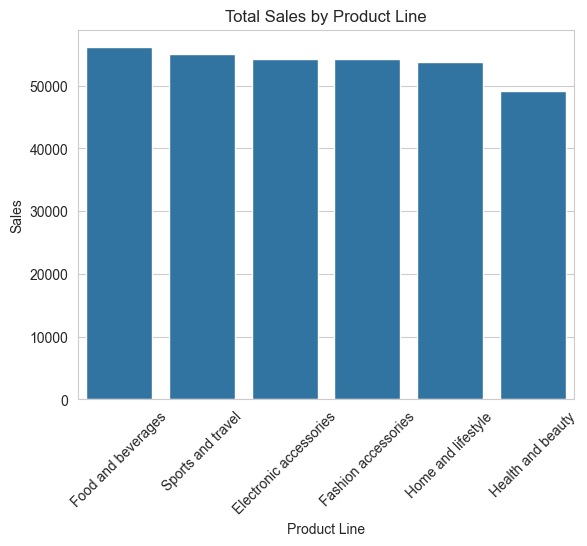

In [29]:
## Visualization
plt.Figure(figsize=(10,6))
sns.barplot(x=sales_product.index, y=sales_product.values)
plt.xticks(rotation=45)
plt.title("Total Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Sales")
plt.show()

In [30]:
## Sales by Branch
sales_branch = df.groupby("Branch")["Sales"].sum()
print(sales_branch)

Branch
Alex     106200.3705
Cairo    106197.6720
Giza     110568.7065
Name: Sales, dtype: float64


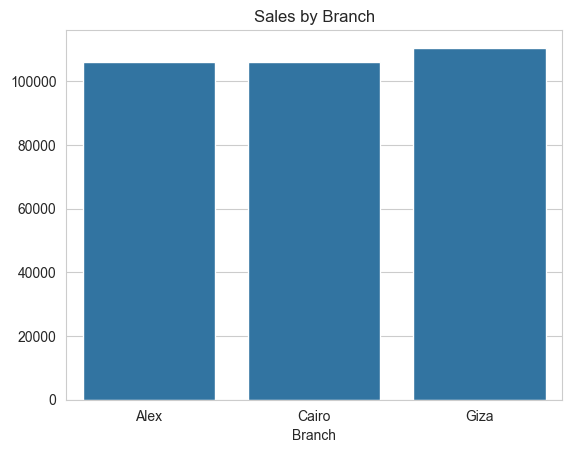

In [ ]:
##Visualization
sns.barplot(x=sales_branch.index, y=sales_branch.values)
plt.title("Sales by Branch")
plt.show()

In [32]:
## Sales by City
sales_city = df.groupby("City")["Sales"].sum()
print(sales_city)

City
Mandalay     106197.6720
Naypyitaw    110568.7065
Yangon       106200.3705
Name: Sales, dtype: float64


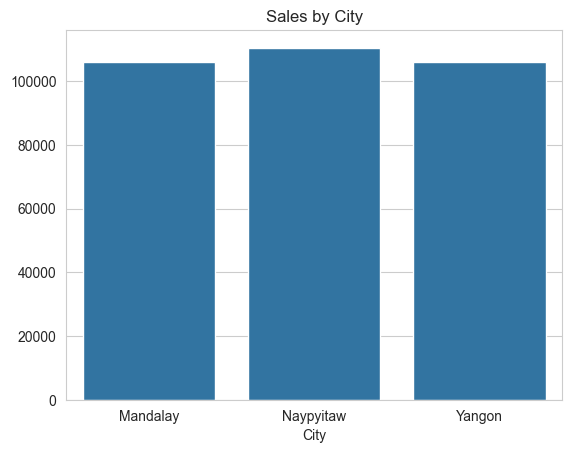

In [33]:
## Visualization
sns.barplot(x=sales_city.index, y=sales_city.values)
plt.title("Sales by City")
plt.show()